# Prompt Engineering

**Core concepts:** chat roles and templates, zero-shot, few-shot, chain-of-thought, prompt
evaluation, structured outputs and constrained decoding, multi-turn context management,
prompt chaining

**Tools:** HuggingFace `transformers`, scikit-learn, pandas

**Models covered:** Qwen3-1.7B, evaluated against the TF-IDF and logistic regression
baseline from Week 4

A prompt is a hyperparameter. It is the thing you change to improve results, and like every
other hyperparameter in this course it has to be measured rather than admired. This notebook
builds the measuring apparatus first, then uses it to decide which prompting techniques
actually earn their cost.

**Runtime:** roughly 20 minutes on a Colab T4.

## 0. The task

Amazon Fine Food Reviews again, and specifically the **same binary sentiment task from
Week 4**: reviews scored 4 or 5 are positive, 1 or 2 are negative, and 3 is dropped as
ambiguous.

Reusing it is the point. You already have a trained classifier for this task and know what
it scores, so every prompt in this notebook can be compared against a real baseline instead
of against nothing.

## 1. Setup

In [1]:
!pip install -q transformers

In [2]:
import time
import json as jsonlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, LogitsProcessor, LogitsProcessorList

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (11, 4)
print("torch:", torch.__version__, "| device:", DEVICE)

torch: 2.11.0+cu128 | device: cuda


In [3]:
MODEL_ID = "Qwen/Qwen3-1.7B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map="auto")
model.eval()

# Decoder-only models must be padded on the LEFT for batched generation, so that
# every sequence ends at the position where generation begins.
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"loaded {MODEL_ID}")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

loaded Qwen/Qwen3-1.7B


That padding detail causes real bugs. With right padding, a batch of prompts of different
lengths would have padding tokens sitting between the prompt and the first generated token,
and the model would continue from the padding instead of from your text.

## 2. Anatomy of a prompt

The single string you type into a chat box is not what the model receives. Instruction-tuned
models are trained on a **conversation format** with named roles, and the tokenizer's chat
template assembles it.

- **system**: standing instructions, persona, constraints. Applies to the whole conversation
- **user**: the request
- **assistant**: the model's reply. During generation this role is opened and left empty for
  the model to fill

The special tokens marking each role were learned during instruction tuning. Getting them
right matters more than most prompt wording.

In [4]:
messages = [
    {"role": "system", "content": "You are a terse assistant. Answer in one word."},
    {"role": "user", "content": "Is this review positive or negative? 'I loved it.'"},
]

rendered = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)

print(rendered)

<|im_start|>system
You are a terse assistant. Answer in one word.<|im_end|>
<|im_start|>user
Is this review positive or negative? 'I loved it.'<|im_end|>
<|im_start|>assistant
<think>

</think>




`add_generation_prompt=True` appends the tokens that open an assistant turn, which is what
tells the model it is its turn to speak. `enable_thinking=False` disables Qwen3's reasoning
mode, which would otherwise wrap every answer in `<think>` blocks.

Two helpers for the rest of the notebook: one to render a prompt, one to generate in batches.

In [5]:
def render(user, system=None):
    msgs = ([{"role": "system", "content": system}] if system else [])
    msgs.append({"role": "user", "content": user})
    return tokenizer.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False)


@torch.no_grad()
def generate_batch(prompts, max_new_tokens=8, batch_size=32, logits_processor=None):
    "Greedy generation over a list of rendered prompts. Deterministic by design."
    outputs = []

    for start in range(0, len(prompts), batch_size):
        chunk = prompts[start:start + batch_size]
        enc = tokenizer(chunk, return_tensors="pt", padding=True).to(model.device)

        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=False,                       # temperature 0, see the Intro to Generative AI notebook, section 5
            pad_token_id=tokenizer.pad_token_id,
            logits_processor=logits_processor,
        )
        gen = out[:, enc["input_ids"].shape[1]:]
        outputs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))

    return [o.strip() for o in outputs]

Greedy decoding throughout. The Introduction to Generative AI notebook showed that sampling
makes the same prompt give different
answers, which would mean a prompt change and sampling noise are indistinguishable. For
evaluation you always want the deterministic setting.

## 3. The evaluation harness, before anything else

This section comes first on purpose. Almost every prompt engineering tutorial shows a
technique, prints one nice-looking output, and moves on. That is not evidence. A prompt that
produces a good answer to the example you tried tells you nothing about the other 500 cases.

You already know how to do this properly, because it is the same discipline as the rest of
the course: a held-out set, a metric, and a baseline.

In [6]:
REVIEWS_PATH = Path("Reviews.csv")   # your Week 4 copy

reviews = pd.read_csv(REVIEWS_PATH, usecols=["Score", "Text"], on_bad_lines="skip")
reviews = reviews.dropna(subset=["Text"])

# Week 4's labelling rule: 4-5 positive, 1-2 negative, 3 dropped
reviews = reviews[reviews["Score"] != 3].copy()
reviews["label"] = (reviews["Score"] >= 4).astype(int)

# Keep reviews short enough that few-shot prompts still fit comfortably in context
reviews = reviews[reviews["Text"].str.len().between(80, 600)]

print(f"{len(reviews):,} usable reviews")
print(reviews["label"].value_counts(normalize=True).rename({0: "negative", 1: "positive"}))

68,675 usable reviews
label
positive    0.845825
negative    0.154175
Name: proportion, dtype: float64


The classes are heavily imbalanced, roughly 80 percent positive, which is normal for product
reviews. We build a **balanced** evaluation set so that accuracy is interpretable and the
majority-class baseline is 50 percent rather than 80.

In [7]:
EVAL_N = 200          # per-class 100, keeps the whole notebook to a few minutes
TRAIN_N = 4000        # for the Week 4 style baseline

rng = np.random.default_rng(SEED)


def balanced_sample(df, n, exclude_idx=None):
    pool = df.drop(index=exclude_idx) if exclude_idx is not None else df
    per_class = n // 2
    parts = [pool[pool["label"] == c].sample(per_class, random_state=SEED) for c in (0, 1)]
    return pd.concat(parts).sample(frac=1, random_state=SEED)


eval_set = balanced_sample(reviews, EVAL_N)
train_set = balanced_sample(reviews, TRAIN_N, exclude_idx=eval_set.index)

print(f"eval:  {len(eval_set)} reviews, {eval_set['label'].mean():.0%} positive")
print(f"train: {len(train_set)} reviews (baseline only, never shown to the LLM)")

eval:  200 reviews, 50% positive
train: 4000 reviews (baseline only, never shown to the LLM)


### The metric, and how much it can tell us

Accuracy on a balanced set, plus a **parse failure rate**: how often the model produced
something we could not read as a label. That second number matters and is usually invisible
in tutorials, because a model that answers "Well, this review seems mostly positive although"
is wrong in a different and more fixable way than a model that answers "negative".

With 200 examples, the 95 percent confidence interval on an accuracy near 0.85 is roughly
plus or minus 5 points. Differences smaller than that are noise. Stating this up front stops
us over-reading small gaps later.

In [8]:
def parse_label(text):
    "Read a label out of free-form model output. Returns 1, 0, or None."
    t = text.lower().strip()
    has_pos, has_neg = "positive" in t, "negative" in t
    if has_pos and not has_neg:
        return 1
    if has_neg and not has_pos:
        return 0
    return None            # both or neither: unparseable


def evaluate_prompt(name, prompt_fn, data=None, max_new_tokens=8,
                    logits_processor=None, verbose=True):
    "Run a prompt-building function over the eval set and score it."
    data = eval_set if data is None else data
    prompts = [prompt_fn(t) for t in data["Text"]]

    start = time.perf_counter()
    raw = generate_batch(prompts, max_new_tokens=max_new_tokens,
                         logits_processor=logits_processor)
    elapsed = time.perf_counter() - start

    preds = [parse_label(r) for r in raw]
    parsed = np.array([p is not None for p in preds])
    # unparseable answers count as wrong, which is the honest accounting
    filled = np.array([p if p is not None else -1 for p in preds])
    accuracy = (filled == data["label"].values).mean()

    result = {
        "prompt": name,
        "accuracy": accuracy,
        "parse_fail": 1 - parsed.mean(),
        "seconds": elapsed,
        "prompt_tokens": int(np.mean([len(tokenizer.encode(p)) for p in prompts])),
    }

    if verbose:
        print(f"{name:<28} acc {accuracy:.3f}   parse-fail {1 - parsed.mean():.1%}   "
              f"{elapsed:.0f}s   {result['prompt_tokens']} tok/prompt")

    return result, raw


results = []

### The baseline: what Week 4 already achieves

Before any prompting, train the Week 4 pipeline. TF-IDF with bigrams into logistic
regression, on 4,000 labelled examples the LLM never sees.

**Predict first.** Based on what you saw from this pipeline in Week 4, guess: what accuracy
will TF-IDF plus logistic regression get on this balanced sentiment task? Write a number
down, then run the next cell.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

start = time.perf_counter()

baseline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5),
    LogisticRegression(max_iter=1000),
)
baseline.fit(train_set["Text"], train_set["label"])

baseline_acc = baseline.score(eval_set["Text"], eval_set["label"])
baseline_time = time.perf_counter() - start

print(f"Week 4 baseline (TF-IDF + LogReg): accuracy {baseline_acc:.3f}")
print(f"trained and evaluated in {baseline_time:.1f}s on CPU")

Week 4 baseline (TF-IDF + LogReg): accuracy 0.885
trained and evaluated in 2.3s on CPU


Hold that number. It came from 4,000 labels, a few seconds of CPU, and no GPU at all.

## 4. Zero-shot

**Zero-shot** means asking for the task with no worked examples. Just the instruction.

In [13]:
def zero_shot(review):
    return render(f"Is the following product review positive or negative?\n\n{review}")


print(zero_shot(eval_set["Text"].iloc[0])[-400:])

<|im_start|>user
Is the following product review positive or negative?

Our dogs do NOT like this and won't eat it. Yes, they have no problem with the Libby's real canned pumpkin, but not this brand.<|im_end|>
<|im_start|>assistant
<think>

</think>




In [14]:
r, raw = evaluate_prompt("zero-shot, vague", zero_shot)
results.append(r)

print("\nsample raw outputs:")
for o in raw[:5]:
    print(f"  {o!r}")

zero-shot, vague             acc 0.870   parse-fail 10.5%   12s   89 tok/prompt

sample raw outputs:
  'The product review is **negative**.'
  'The product review is **neutral**.'
  'The product review is **negative**.'
  'The product review is **positive**.'
  'The product review is **positive**.'


Look at the raw outputs before the accuracy. If the model is answering in sentences, the
parse failure rate is doing real damage and the fix is the instruction, not the technique.

### Being specific about the output

The most reliable improvement in prompting is also the least interesting: say exactly what
you want back. Constrain the format, constrain the length, and give the model no room to be
conversational.

In [15]:
def zero_shot_specific(review):
    return render(
        "Classify the sentiment of the product review below.\n"
        "Answer with exactly one word: positive or negative.\n"
        "Do not explain.\n\n"
        f"Review: {review}\n"
        "Sentiment:")


r, raw = evaluate_prompt("zero-shot, specific", zero_shot_specific)
results.append(r)

print("\nsample raw outputs:")
for o in raw[:5]:
    print(f"  {o!r}")

zero-shot, specific          acc 0.925   parse-fail 3.0%   7s   109 tok/prompt

sample raw outputs:
  'negative'
  'negative'
  'negative'
  'positive'
  'positive'


### Adding a system prompt

The system role sets standing behaviour. It is the right place for persona, tone and format
rules that apply to every request, rather than repeating them in each user message.

In [16]:
SYSTEM = ("You are a precise sentiment classification system. "
          "You reply with exactly one word, either 'positive' or 'negative', and nothing else.")


def zero_shot_system(review):
    return render(f"Review: {review}\nSentiment:", system=SYSTEM)


r, raw = evaluate_prompt("zero-shot + system", zero_shot_system)
results.append(r)

zero-shot + system           acc 0.935   parse-fail 1.5%   6s   117 tok/prompt


## 5. Few-shot

**Few-shot** prompting puts worked examples in the prompt. The model infers the pattern from
them, including the output format, without any weight updates. This is why it is sometimes
called in-context learning.

The examples come from the training split, never the evaluation set. Taking them from the
evaluation set would be leaking test data into the model, exactly as it would be in any
other model.

In [17]:
def build_examples(n_per_class=2, seed=SEED):
    "Pull balanced worked examples from the training split."
    picks = []
    for label in (0, 1):
        sub = train_set[train_set["label"] == label].sample(n_per_class, random_state=seed)
        picks += [(t, "positive" if label else "negative") for t in sub["Text"]]

    rng_local = np.random.default_rng(seed)
    rng_local.shuffle(picks)          # interleave so the labels do not arrive in blocks
    return picks


EXAMPLES = build_examples(2)

for text, label in EXAMPLES:
    print(f"[{label}] {text[:90]}...")

[positive] I don't want to say that one chocolate is better than another. That's a matter of individu...
[positive] This is a good value, we save even more with scheduled monthly delivery. Really helps with...
[negative] It seems alot of items on Amazon get undeserved glowing reviews.  I tried these (original ...
[negative] These had next to zero smell. They did pop, as expected, however almost no smell whatsoeve...


In [18]:
def make_few_shot(examples):
    block = "\n\n".join(f"Review: {t}\nSentiment: {lab}" for t, lab in examples)

    def prompt_fn(review):
        return render(f"{block}\n\nReview: {review}\nSentiment:", system=SYSTEM)

    return prompt_fn


r, raw = evaluate_prompt("few-shot (4 examples)", make_few_shot(EXAMPLES))
results.append(r)

few-shot (4 examples)        acc 0.905   parse-fail 0.0%   15s   332 tok/prompt


### Does more examples keep helping?

Each example costs tokens in every single request, so this is a real cost question and not
just an accuracy one.

In [19]:
shot_results = []

for n in [1, 2, 4, 8]:
    ex = build_examples(n // 2 if n > 1 else 1)[:n]
    r, _ = evaluate_prompt(f"few-shot ({n} examples)", make_few_shot(ex))
    shot_results.append({**r, "n_examples": n})

results.extend(shot_results)

few-shot (1 examples)        acc 0.960   parse-fail 0.5%   8s   160 tok/prompt
few-shot (2 examples)        acc 0.915   parse-fail 0.0%   9s   195 tok/prompt
few-shot (4 examples)        acc 0.905   parse-fail 0.0%   15s   332 tok/prompt
few-shot (8 examples)        acc 0.775   parse-fail 0.0%   23s   537 tok/prompt


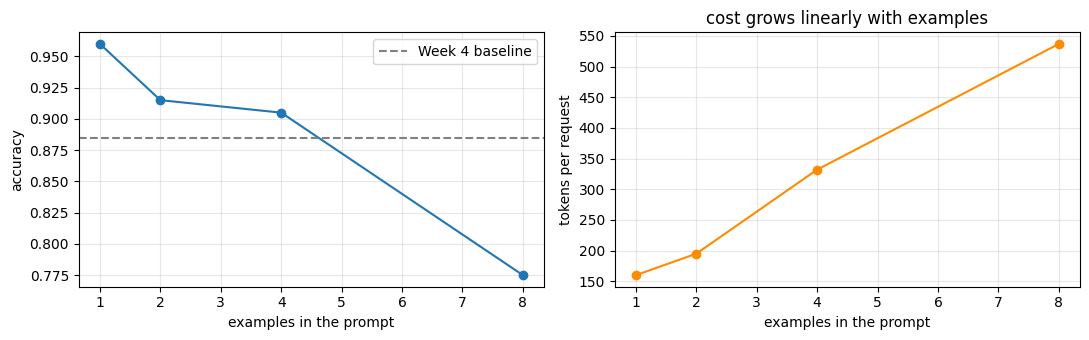

In [20]:
sr = pd.DataFrame(shot_results)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(sr["n_examples"], sr["accuracy"], "o-")
axes[0].axhline(baseline_acc, color="gray", ls="--", label="Week 4 baseline")
axes[0].set_xlabel("examples in the prompt")
axes[0].set_ylabel("accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(sr["n_examples"], sr["prompt_tokens"], "o-", color="darkorange")
axes[1].set_xlabel("examples in the prompt")
axes[1].set_ylabel("tokens per request")
axes[1].set_title("cost grows linearly with examples")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Accuracy usually rises quickly from zero to a few examples and then flattens, while token
cost rises without limit. The first two examples do most of the work. Remember the plus or
minus 5 point confidence interval when reading the flat part of this curve: most of the
wiggle there is noise.

### Example choice matters as much as example count

In [21]:
variation = []
for seed in [0, 1, 2]:
    ex = build_examples(2, seed=seed)
    r, _ = evaluate_prompt(f"few-shot, example set {seed}", make_few_shot(ex), verbose=False)
    variation.append(r["accuracy"])
    print(f"example set {seed}: accuracy {r['accuracy']:.3f}")

print(f"\nspread from example choice alone: {max(variation) - min(variation):.3f}")

example set 0: accuracy 0.910
example set 1: accuracy 0.925
example set 2: accuracy 0.930

spread from example choice alone: 0.020


The same technique with the same number of examples, differing only in which examples were
drawn, moves the score. That spread is worth knowing about, because it means a single
few-shot result is not a reliable measurement of a prompt. When comparing prompt strategies
seriously, vary the example set and report the spread, exactly as you would report variance
across cross-validation folds.

### Checkpoint: look at one review, not just the average

The numbers above are aggregates. Find a review the zero-shot prompt actually got wrong, and
see whether few-shot fixes it.

**Task**

1. Run the cell below, it searches the first 30 eval reviews for one where the zero-shot
   prediction disagrees with the true label.
2. Run that same review through the few-shot prompt and check whether the prediction
   changes.
3. Read the review yourself. Does the true label seem obvious to a person, or is this
   actually an ambiguous case?

In [22]:
zero_preds = generate_batch([zero_shot_system(t) for t in eval_set["Text"].head(30)],
                            max_new_tokens=8)

mismatch_idx = next(
    i for i, (pred, true) in enumerate(zip(zero_preds, eval_set["label"].head(30)))
    if parse_label(pred) != true
)

review_text = eval_set["Text"].iloc[mismatch_idx]
true_label = "positive" if eval_set["label"].iloc[mismatch_idx] else "negative"
few_shot_pred = generate_batch([make_few_shot(EXAMPLES)(review_text)], max_new_tokens=8)[0]

print("review:    ", review_text[:250])
print("true label:", true_label)
print("zero-shot: ", zero_preds[mismatch_idx])
print("few-shot:  ", few_shot_pred)

review:     This is a very tasty tea for the winter.  But, if you let it steep to long it can get so sweet it will make your teeth hurt.  The list of ingredients listed in Amazon's blurb seems improbable.  It has a strong, complex cinnamon flavor. I recommend th
true label: positive
zero-shot:  negative
few-shot:   negative


## 6. Chain-of-thought

**Chain-of-thought** prompting asks the model to reason step by step before answering. The
intermediate tokens give the model somewhere to do work: because it computes one token at a
time with no scratchpad, writing out reasoning is literally how it thinks.

It reliably helps on multi-step problems such as arithmetic and logic. Whether it helps on a
simple classification task is exactly the sort of assumption worth testing rather than
inheriting.

In [23]:
def chain_of_thought(review):
    return render(
        "Classify the sentiment of the review below.\n"
        "First give one short sentence of reasoning, then on a new line write "
        "'Answer: positive' or 'Answer: negative'.\n\n"
        f"Review: {review}",
        system="You are a careful sentiment analyst.")


r, raw = evaluate_prompt("chain-of-thought", chain_of_thought, max_new_tokens=80)
results.append(r)

print("\nsample output:")
print(raw[0][:400])

chain-of-thought             acc 0.895   parse-fail 4.0%   38s   128 tok/prompt

sample output:
The reviewer is expressing that their dogs do not like the brand's canned pumpkin and won't eat it, while noting that they do like another brand. This indicates a negative sentiment towards the specific product being reviewed.

Answer: negative


Compare the accuracy against the few-shot result, and then compare the runtime. Chain-of-
thought generated roughly ten times as many tokens per request. On a task where the answer
is mostly a matter of reading the tone of one paragraph, there are no intermediate steps to
externalise, so the extra tokens usually buy little.

The lesson generalises: chain-of-thought is a tool for problems with actual steps. Applying
it everywhere is a common and expensive habit.

## 7. The comparison

In [24]:
summary = pd.DataFrame(results).drop_duplicates(subset="prompt", keep="first")
summary = summary[["prompt", "accuracy", "parse_fail", "prompt_tokens", "seconds"]]

baseline_row = pd.DataFrame([{
    "prompt": "Week 4: TF-IDF + LogReg", "accuracy": baseline_acc,
    "parse_fail": 0.0, "prompt_tokens": 0, "seconds": baseline_time,
}])

full = pd.concat([baseline_row, summary]).reset_index(drop=True)
display(full.style.format({"accuracy": "{:.3f}", "parse_fail": "{:.1%}",
                           "seconds": "{:.0f}"}).background_gradient(subset=["accuracy"]))

,prompt,accuracy,parse_fail,prompt_tokens,seconds
0,Week 4: TF-IDF + LogReg,0.885,0.0%,0,2
1,"zero-shot, vague",0.870,10.5%,89,12
2,"zero-shot, specific",0.925,3.0%,109,7
3,zero-shot + system,0.935,1.5%,117,6
4,few-shot (4 examples),0.905,0.0%,332,15
5,few-shot (1 examples),0.960,0.5%,160,8
6,few-shot (2 examples),0.915,0.0%,195,9
7,few-shot (8 examples),0.775,0.0%,537,23
8,chain-of-thought,0.895,4.0%,128,38


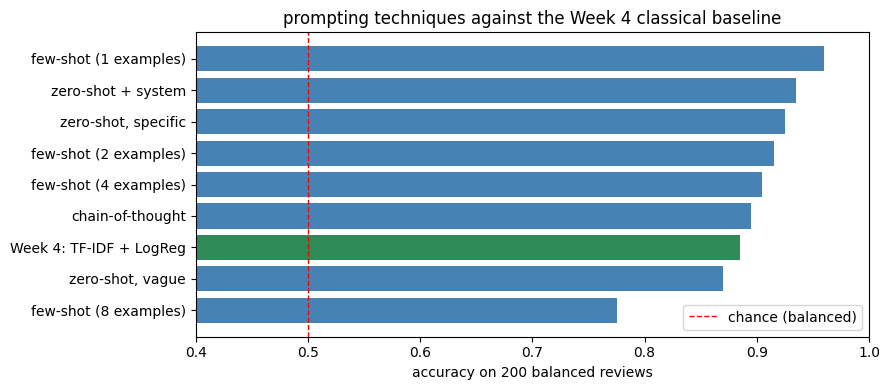

In [25]:
plot_df = full.set_index("prompt")["accuracy"].sort_values()
colors = ["seagreen" if "Week 4" in i else "steelblue" for i in plot_df.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_df.index, plot_df.values, color=colors)
ax.axvline(0.5, color="red", ls="--", lw=1, label="chance (balanced)")
ax.set_xlabel("accuracy on 200 balanced reviews")
ax.set_xlim(0.4, 1.0)
ax.legend()
ax.set_title("prompting techniques against the Week 4 classical baseline")
plt.tight_layout()
plt.show()

### Reading this honestly

Two conclusions, and the second is the important one.

**Within prompting, specificity and a couple of examples do most of the work.** The jump from
a vague instruction to a specific one, and from zero-shot to a few examples, is where the
gains are. Elaborate techniques add little on a task this simple.

**A logistic regression from Week 4 is competitive with, and may beat, a 1.7 billion
parameter language model on this task.** It also trains in seconds on a CPU, runs thousands
of times faster at inference, and its errors are inspectable.

This is not an argument against LLMs. It is an argument about tool selection. Sentiment
classification with 4,000 labels is a solved problem with a cheap, excellent classical
solution. The LLM's advantage appears when you have **no labelled data**, when the task
changes weekly, or when the output is not a label at all: summarising the reviews, extracting
the specific complaint, or answering a question about them. Those are things logistic
regression cannot do at any price.

The right question is never "can an LLM do this" but "what is the cheapest thing that
passes my evaluation".

## 8. Structured outputs

Every result above depended on `parse_label` reading a word out of free-form prose. That is
fragile, and the parse failure column shows the cost.

In a pipeline you need a guarantee, not a hope. There are three levels.

**Level 1: ask nicely.** Put "reply with JSON" in the prompt. Works most of the time. Fails
unpredictably, usually by adding a friendly preamble or wrapping the JSON in a code fence.

In [26]:
def json_prompt(review):
    return render(
        'Analyse the review below. Reply with only a JSON object with keys '
        '"sentiment" (either "positive" or "negative") and "confidence" (0 to 1).\n\n'
        f"Review: {review}",
        system="You output only valid JSON. No preamble, no code fences.")


sample = eval_set["Text"].head(8).tolist()
raw_json = generate_batch([json_prompt(t) for t in sample], max_new_tokens=40)

ok = 0
for out in raw_json:
    try:
        jsonlib.loads(out)
        ok += 1
        print(f"  valid   {out!r}")
    except jsonlib.JSONDecodeError:
        print(f"  INVALID {out[:70]!r}")

print(f"\n{ok}/{len(raw_json)} parsed as valid JSON")

  valid   '{"sentiment": "negative", "confidence": 0.95}'
  valid   '{"sentiment": "mixed", "confidence": 0.7}'
  valid   '{"sentiment": "negative", "confidence": 0.95}'
  valid   '{"sentiment": "positive", "confidence": 0.85}'
  valid   '{"sentiment": "mixed", "confidence": 0.7}'
  valid   '{"sentiment": "positive", "confidence": 0.95}'
  valid   '{"sentiment": "negative", "confidence": 0.85}'
  valid   '{"sentiment": "mixed", "confidence": 0.75}'

8/8 parsed as valid JSON


**Level 2: constrained decoding.** Instead of hoping, make invalid output impossible. At each
step the model produces a score for every token in the vocabulary. If we set the scores of
disallowed tokens to negative infinity before sampling, they cannot be chosen.

For a classification task the allowed set is tiny: the tokens that begin "positive" and
"negative". A `LogitsProcessor` is where transformers lets you intervene.

In [27]:
class AllowOnlyTokens(LogitsProcessor):
    "Mask every token except an allowed set, making invalid output impossible."

    def __init__(self, allowed_token_ids):
        self.allowed = torch.tensor(sorted(set(allowed_token_ids)))

    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, float("-inf"))
        mask[:, self.allowed.to(scores.device)] = scores[:, self.allowed.to(scores.device)]
        return mask


# the model may write " positive" or "positive"; allow the first token of each spelling
label_words = ["positive", "negative", " positive", " negative",
               "Positive", "Negative", " Positive", " Negative"]
allowed_ids = [tokenizer.encode(w)[0] for w in label_words]

print("allowed first tokens:")
for w, i in zip(label_words, allowed_ids):
    print(f"  {w!r:<12} -> id {i:<8} decodes to {tokenizer.decode([i])!r}")

allowed first tokens:
  'positive'   -> id 30487    decodes to 'positive'
  'negative'   -> id 42224    decodes to 'negative'
  ' positive'  -> id 6785     decodes to ' positive'
  ' negative'  -> id 8225     decodes to ' negative'
  'Positive'   -> id 35490    decodes to 'Positive'
  'Negative'   -> id 38489    decodes to 'Negative'
  ' Positive'  -> id 43903    decodes to ' Positive'
  ' Negative'  -> id 50857    decodes to ' Negative'


In [28]:
constrained = LogitsProcessorList([AllowOnlyTokens(allowed_ids)])

r, raw = evaluate_prompt("few-shot + constrained", make_few_shot(EXAMPLES),
                         max_new_tokens=1, logits_processor=constrained)
results.append(r)

print("\nevery output is now a valid label:")
print(" ", set(raw))

few-shot + constrained       acc 0.905   parse-fail 0.0%   15s   332 tok/prompt

every output is now a valid label:
  {'negative', 'positive'}


The parse failure rate is zero by construction, and generation is faster because only one
token is needed. This is the same mechanism behind the "strict JSON schema" modes offered by
hosted providers: a schema is compiled into a state machine, and at each step any token that
would break the schema gets zero probability.

**Level 3: a schema library.** For real JSON with nested fields you would not hand-write the
mask. `outlines` and `xgrammar` compile a Pydantic model or JSON schema into exactly this
kind of constraint for local models. Every major API provider now offers an equivalent
server-side. The mechanism is what you just built.

The habit worth taking: **define the output shape first, then write the prompt.** Schema
first, prompt second.

### Checkpoint: fix the broken output

Three outputs a real "ask nicely" JSON prompt (Level 1) could plausibly produce. For each,
`json.loads` either fails outright or succeeds on something wrong.

```
1. 'Sure! Here is the sentiment analysis: {"sentiment": "positive", "confidence": 0.9}'
2. '```json
{"sentiment": "negative", "confidence": 0.8}
```'
3. '{"sentiment": "positive", "confidence": "very high"}'
```

For each: does `json.loads` raise an error, or silently succeed on something wrong? If it
silently succeeds, what breaks downstream anyway? Which level, 1, 2, or 3, would have
prevented it?

In [ ]:
# Your diagnosis here, one line per case.
#
# 1. ...
# 2. ...
# 3. ...

<details>
<summary>Solution</summary>

**Case 1** raises a `JSONDecodeError`. `json.loads` requires the entire string to be valid
JSON, and the preamble breaks that. A stronger system prompt, still Level 1, sometimes helps,
but not reliably, which is exactly the "fails unpredictably" problem this section opened
with.

**Case 2** also raises. The code fence characters are not valid JSON syntax. A quick patch is
stripping the code fence markers before parsing, but that is a fix on top of a fundamentally
unreliable approach, not a real solution.

**Case 3** is the dangerous one: `json.loads` succeeds. The dictionary is well-formed, but
`confidence` is a string, not a number, so `result["confidence"] * 100` raises a `TypeError`
three steps downstream, far from where the actual problem started.

Only Level 2, constrained decoding, or Level 3, a schema library, rules out all three by
construction rather than catching them after the fact. That is the argument the rest of this
section makes: for anything that runs unattended, "ask nicely" is not a fix, it is a bet.

</details>

## 9. Multi-turn conversation

The model is stateless. It has no memory of previous exchanges. A chat interface works by
resending the entire conversation on every turn, which is why the context window from the Introduction to Generative AI notebook
is the binding constraint on how long a conversation can run.

In [29]:
@torch.no_grad()
def chat(history, user_message, max_new_tokens=60):
    "Append a user turn, generate a reply, return the extended history."
    history = history + [{"role": "user", "content": user_message}]

    text = tokenizer.apply_chat_template(
        history, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    enc = tokenizer(text, return_tensors="pt").to(model.device)

    out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    reply = tokenizer.decode(out[0, enc["input_ids"].shape[1]:],
                             skip_special_tokens=True).strip()

    return history + [{"role": "assistant", "content": reply}], reply, enc["input_ids"].shape[1]

In [30]:
history = [{"role": "system", "content": "You are a concise assistant."}]

turns = [
    "I bought a bag of dark roast coffee beans last week.",
    "It tasted burnt and bitter. Was that a good purchase?",
    "What was I talking about?",          # tests whether earlier turns are still in context
]

for turn in turns:
    history, reply, n_tokens = chat(history, turn)
    print(f"USER  ({n_tokens:>4} tokens sent): {turn}")
    print(f"MODEL: {reply}\n")

USER  (  35 tokens sent): I bought a bag of dark roast coffee beans last week.
MODEL: Great! Dark roast coffee beans are typically used for stronger, more flavorful brews. Let me know if you'd like suggestions for brewing methods or recipes!

USER  (  88 tokens sent): It tasted burnt and bitter. Was that a good purchase?
MODEL: It sounds like the beans may have been under-processed or stored improperly, which can lead to a burnt or bitter taste. Dark roast beans should generally offer a balanced flavor if properly roasted. If you're not satisfied, consider trying a different batch or checking storage conditions. Let me know if you'd

USER  ( 164 tokens sent): What was I talking about?
MODEL: You were talking about the dark roast coffee beans you bought, and how they tasted burnt and bitter. I was helping you assess whether it was a good purchase. Let me know if you'd like further advice!



The third answer shows the model still has the first turn available, because the whole
history was resent. Watch the token count climb with every turn: that is the cost of memory,
paid again on each request.

Long conversations therefore need a management strategy, and the common ones are:

- **Truncate**: drop the oldest turns. Simple, and the model forgets the beginning
- **Summarise**: periodically replace old turns with a short summary. Cheaper than the full
  history, and lossy
- **Retrieve**: store turns externally and pull back only the relevant ones. This is the
  retrieval notebook's technique applied to conversation history

The system message should survive all of these. Dropping it is a common bug that makes a
model mysteriously change personality partway through a long chat.

## 10. Prompt chaining

When one prompt has to do several things at once, quality drops and failures become hard to
diagnose. **Chaining** splits the work into steps, each with a checkable output, and feeds one
into the next.

Chained steps are easier to debug, easier to evaluate individually, and let you use a
constrained output at each stage. The cost is more calls and more latency.

Below: extract what the complaint was, then decide whether it concerns the product or the
delivery, then write a one-line reply. Each stage does one job.

In [31]:
negative_reviews = eval_set[eval_set["label"] == 0]["Text"].head(4).tolist()


def step_extract(review):
    return render(f"In one short phrase, what is the main complaint in this review?\n\n{review}",
                  system="You reply with a short phrase and nothing else.")


def step_categorise(complaint):
    return render(f"Complaint: {complaint}\n\nIs this about the PRODUCT or the DELIVERY?",
                  system="Reply with exactly one word: PRODUCT or DELIVERY.")


def step_reply(complaint, category):
    return render(
        f"A customer complained about: {complaint} (category: {category}).\n"
        "Write one sentence apologising and offering a next step.",
        system="You are a polite customer service agent. One sentence only.")

In [32]:
complaints = generate_batch([step_extract(r) for r in negative_reviews], max_new_tokens=20)
categories = generate_batch([step_categorise(c) for c in complaints], max_new_tokens=4)
replies = generate_batch([step_reply(c, k) for c, k in zip(complaints, categories)],
                         max_new_tokens=45)

for review, complaint, category, reply in zip(negative_reviews, complaints, categories, replies):
    print(f"REVIEW:    {review[:90]}...")
    print(f"  complaint: {complaint}")
    print(f"  category:  {category}")
    print(f"  reply:     {reply}\n")

REVIEW:    Our dogs do NOT like this and won't eat it. Yes, they have no problem with the Libby's rea...
  complaint: The main complaint is that the dogs do not like the brand of canned pumpkin.
  category:  PRODUCT
  reply:     We apologize for the inconvenience and would like to offer a free replacement or alternative product to ensure you're satisfied.

REVIEW:    As posted in the "black cherry" review, 33 grams of sugar is way too much for me but may b...
  complaint: The main complaint is that 33 grams of sugar is too much for the reviewer.
  category:  PRODUCT
  reply:     We apologize for the confusion and appreciate your feedback. We will adjust the sugar content to better meet your expectations and will reach out to you directly to discuss the next steps.

REVIEW:    Ew...I love Canada Dry and Schwepps, and I decided to try this brand because it was cheape...
  complaint: The main complaint is that the soda tastes overly saccharine and gross.
  category:  PRODUCT
  reply:     

Each intermediate value is visible and checkable. If the replies are poor you can see whether
the extraction or the categorisation went wrong, which is impossible when one prompt does
everything and returns only the final sentence.

The categorisation step is a good candidate for the constrained decoding from section 8,
since its output space is exactly two words.

**Discuss, in pairs, before the exercise.** Pick one task, from a past job, a project, or
just something you do regularly, that a single prompt would struggle with. Sketch it as a
chain: what would each step take in, what would it hand to the next step, and where would
you add the constrained-output trick from section 8?

## 11. Exercise

Roughly 15 minutes.

Section 5 showed that the choice of few-shot examples moves accuracy by a few points, using
randomly drawn examples. A common technique is to choose examples that are **similar to the
input** rather than fixed, on the theory that a nearby example is more informative.

You have the tool for this already: embeddings.

**Task**

1. Embed the `Text` of 500 training reviews and all 200 evaluation reviews using
   `sentence-transformers/all-MiniLM-L6-v2`, as in the Introduction to Generative AI notebook, section 7.
2. Write `dynamic_few_shot(review)` which, for each evaluation review, finds its 4 nearest
   training reviews by cosine similarity and builds a few-shot prompt from those, with their
   true labels.
3. Evaluate it and compare against the fixed 4-example prompt from section 5.
4. Answer in a comment: does it help? What extra cost does it add at inference time compared
   with fixed examples?

**Hint:** `evaluate_prompt` takes any function of a review string, so `dynamic_few_shot` can
do a lookup inside it. Precompute the embeddings once outside the function.

In [ ]:
# Your answer here.
#
# !pip install -q sentence-transformers
# from sentence_transformers import SentenceTransformer
#
# embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(DEVICE))
# pool = train_set.sample(500, random_state=SEED)
# ...

<details>
<summary>Solution</summary>

```python
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=str(DEVICE))

pool = train_set.sample(500, random_state=SEED).reset_index(drop=True)
pool_emb = embedder.encode(pool["Text"].tolist(), normalize_embeddings=True, batch_size=64)
eval_emb = embedder.encode(eval_set["Text"].tolist(), normalize_embeddings=True, batch_size=64)

# map each eval review to its nearest training examples
neighbours = np.argsort(-(eval_emb @ pool_emb.T), axis=1)[:, :4]
lookup = {text: row for text, row in zip(eval_set["Text"], neighbours)}


def dynamic_few_shot(review):
    idx = lookup[review]
    examples = [(pool["Text"].iloc[i],
                 "positive" if pool["label"].iloc[i] else "negative") for i in idx]
    block = "\n\n".join(f"Review: {t}\nSentiment: {lab}" for t, lab in examples)
    return render(f"{block}\n\nReview: {review}\nSentiment:", system=SYSTEM)


r_dyn, _ = evaluate_prompt("few-shot, nearest-neighbour", dynamic_few_shot)

fixed = [x for x in results if x["prompt"] == "few-shot (4 examples)"][0]
print(f"\nfixed examples:   {fixed['accuracy']:.3f}")
print(f"nearest-neighbour: {r_dyn['accuracy']:.3f}")
print(f"difference:        {r_dyn['accuracy'] - fixed['accuracy']:+.3f}")
```

**What you should see.** Usually a small improvement, often within the plus or minus 5 point
confidence interval, so on 200 examples you probably cannot call it significant. Report it as
"no measurable difference at this sample size" rather than claiming a win.

**Why it might help.** A nearby example is more likely to share vocabulary, product type and
review style, so the pattern the model has to generalise is shorter. The technique earns its
keep on harder tasks with many classes, where a random example may be from an irrelevant
category entirely.

**The cost.** Fixed examples mean the prompt prefix is identical for every request, which
lets both local servers and hosted APIs cache it. Dynamic examples change the prefix every
time, so that caching is lost, and you add an embedding lookup per request. On a
high-throughput service that is a real expense for a gain you could not measure here.

This is the recurring theme of the notebook: the technique is not free, so measure before
adopting it.

</details>

## 12. Where this sits in practice

**Prompts are hyperparameters, and the harness matters more than the prompt**

The single most valuable thing in this notebook is section 3, not any individual technique.
Teams that evaluate prompts against a fixed set with a real metric improve steadily. Teams
that try a prompt, read one output and ship it are guessing, and they cannot tell whether a
change helped, because they never measured. You already had this discipline from the rest of
the course. It transfers directly.

**The techniques, ranked by what they actually deliver**

Being specific about the output format is first and it is not close. Two to four examples is
second. A system prompt for standing rules is third. Chain-of-thought is valuable on tasks
with genuine intermediate steps and wasteful elsewhere. Beyond that the returns get small
fast, and effort is usually better spent on the data going into the prompt than on the prompt
wording.

**Structured output is the difference between a demo and a pipeline**

Free-form text parsed with string matching will fail eventually, silently, in production. The
industry moved decisively toward schema-constrained generation, and the current consensus is
schema first, prompt second. What section 8 built by hand is what the provider APIs do for
you.

**What is next**

Every technique here supplies the model with better instructions. None of it supplies better
**information**: the model still answers from what it learned during training, with the
failure mode the Introduction to Generative AI notebook's section 8 demonstrated. The retrieval notebook fixes that by putting the
relevant facts into the prompt, which turns out to be the highest-leverage prompt engineering
of all.

## 13. Further reading

- [Anthropic's prompt engineering guide](https://docs.claude.com/en/docs/build-with-claude/prompt-engineering/overview)
  Practical, current, and organised by technique with worked examples. The most useful single
  reference for the material in sections 4 to 6.

- [Brown et al., Language Models are Few-Shot Learners](https://arxiv.org/abs/2005.14165)
  The GPT-3 paper that introduced in-context learning. Worth reading for the scaling curves
  showing how few-shot ability emerges with model size, which explains why our 1.7B model
  gains less from examples than a frontier model would.

- [Wei et al., Chain-of-Thought Prompting Elicits Reasoning in Large Language
  Models](https://arxiv.org/abs/2201.11903) The chain-of-thought paper. Note that its gains
  are demonstrated on arithmetic and symbolic reasoning, which is exactly the boundary
  section 6 ran into.

- [Outlines documentation](https://dottxt-ai.github.io/outlines/) The library that generalises
  section 8's `LogitsProcessor` to full JSON schemas and regular expressions for local models.
  The introduction explains constrained decoding better than most papers.